In [153]:
import numpy as np

In [154]:
def entropy(y):
    count = np.unique(y, return_counts=True)
    p = count[1] / len(y)
    log = np.log2(p)
    res = -np.sum(p * log)
    return res

In [155]:
def information_gain(x_colum: np.array, y: np.array):
    ent_y = entropy(y)
    for x in np.unique(x_colum):
        mask = x_colum == x
        label_y = y[mask]
        ent_y -= (len(label_y) / len(x_colum)) * entropy(label_y)
    return ent_y

In [156]:
def split_with_greatest_inf_gain(data, labels):
    max_gain = 0
    arr_idx = None
    for idx in range(data.shape[1]):  # iterate over columns (features)
        col = data[:, idx]
        inf_gain = information_gain(col, labels)
        if inf_gain > max_gain:
            max_gain = inf_gain
            arr_idx = idx
    return arr_idx

In [157]:
def custom_tree(data: np.ndarray, labels: np.ndarray, depth=0, max_depth=3):
    if entropy(labels) == 0:
        return labels[0]
    if depth == max_depth:
        return np.bincount(labels).argmax()
    idx = split_with_greatest_inf_gain(data, labels)
    best_feature = data[:, idx]  # get column idx
    subtrees = {}
    for x in np.unique(best_feature):
        mask = best_feature == x
        sub_data = data[mask]    # rows where feature == x
        sub_labels = labels[mask]
        subtrees[x] = custom_tree(sub_data, sub_labels, depth + 1, max_depth)
    return {'feature': idx, 'branches': subtrees}

In [158]:
def predict(tree: dict, sample: np.ndarray) -> int:
    feature = sample[tree["feature"]]
    res = tree["branches"][feature]
    if not isinstance(res, dict):
        return res
    return predict(res, sample)

In [159]:
# Case 1: feature perfectly separates the labels
print(information_gain(np.array([0, 0, 1, 1]), np.array([0, 0, 1, 1])))

# Case 2: feature tells you nothing
print(information_gain(np.array([0, 1, 0, 1]), np.array([0, 0, 1, 1])))

data = np.array([
    [0, 1, 1, 1],
    [1, 0, 0, 0],
    [1, 0, 1, 0],
    [0, 0, 0, 0],
    [1, 1, 1, 1]
])
labels = np.array([1, 0, 1, 0, 0])
tree1 = custom_tree(data, labels)
print(f'tree: {custom_tree}')
x = predict(tree1, np.array([1, 0, 1, 1]))
print(x)

1.0
0.0
tree: <function custom_tree at 0x0000013B62380EB0>
1


{
    'feature': 2, 'branches': {
        np.int64(0): np.int64(0), np.int64(1): {
            'feature': 0, 'branches': {
                np.int64(0): np.int64(1), np.int64(1): {
                    'feature': 1, 'branches': {
                        np.int64(0): np.int64(1), np.int64(1): np.int64(0)
                    }
                }
            }
        }
    }
}

In [160]:
import pandas as pd
import matplotlib.pyplot as plt

In [161]:
file_path = "diabetes.csv"
diabetes_data = pd.read_csv(file_path)
# Filter rows where either Glucose or BMI are zero
filtered_data = diabetes_data[(diabetes_data['Glucose'] != 0) & (diabetes_data['BMI'] != 0)]
# Now extract X and y
X = filtered_data[['Glucose', 'BMI']].values
y = filtered_data['Outcome'].values

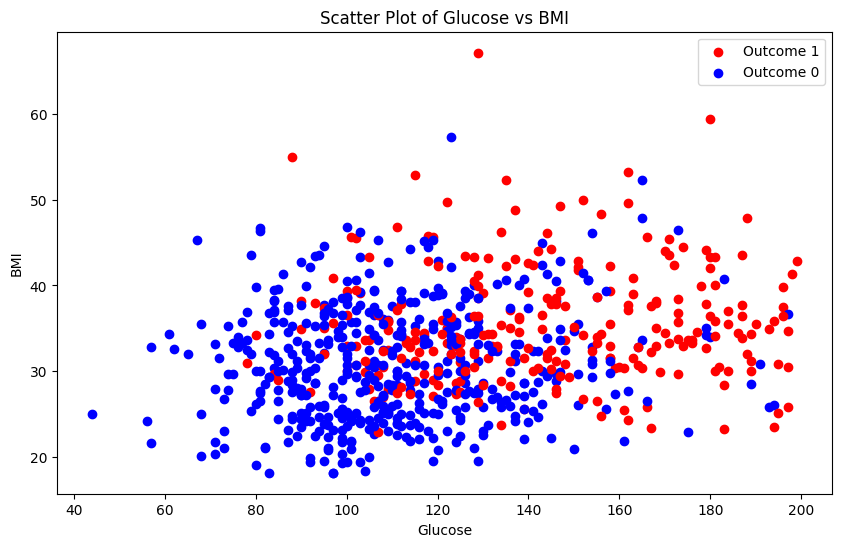

In [162]:
# Create a scatter plot (διάγραμμα διασποράς)
plt.figure(figsize=(10, 6))
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i, 0], X[i, 1], color='blue', label='Outcome 0' if 'Outcome 0' not in plt.gca().get_legend_handles_labels()[1] else "")
    else:
        plt.scatter(X[i, 0], X[i, 1], color='red', label='Outcome 1' if 'Outcome 1' not in plt.gca().get_legend_handles_labels()[1] else "")

# Adding labels and title
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Scatter Plot of Glucose vs BMI')
plt.legend()
plt.show()

In [163]:
# import the necessary libraries
from sklearn import tree #import the tree module from the scikit-learn library
from sklearn.tree import DecisionTreeClassifier # used to create a decision tree classifier
from sklearn.metrics import accuracy_score # used to calculate the accuracy of a classification model
depth = 2

In [164]:
# Create a decision tree of depth 2
depth_two_tree = DecisionTreeClassifier(max_depth=depth)
# Fit the model on the training data
depth_two_tree.fit(X,y)
# Make predictions
y_pred2 = depth_two_tree.predict(X)

# Compute accuracy
accuracy = accuracy_score(y, y_pred2)
print("Accuracy of the depth two decision tree:", accuracy)

Accuracy of the depth two decision tree: 0.7726063829787234


In [165]:
data = custom_tree(X, y)
pred = predict(data, X)
print(pred)

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed